In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd


1 : DATA FILTERING

In [46]:
df = pd.read_csv("clustering_data.csv")

#cleaning the strings of spaces if present
df.columns = df.columns.str.strip()
df["StateName"] = df["StateName"].str.strip()
home_df = df[df["StateName"] == "GUJARAT"]
home_df["Latitude"] = pd.to_numeric(home_df["Latitude"], errors="coerce")
home_df["Longitude"] = pd.to_numeric(home_df["Longitude"], errors="coerce")
home_df = home_df.dropna(subset=["Latitude", "Longitude"])

C:\Users\tilak\AppData\Local\Temp\ipykernel_19308\403818101.py:1: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("clustering_data.csv")
C:\Users\tilak\AppData\Local\Temp\ipykernel_19308\403818101.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_df["Latitude"] = pd.to_numeric(home_df["Latitude"], errors="coerce")
C:\Users\tilak\AppData\Local\Temp\ipykernel_19308\403818101.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  home_d

2 : DATA VISUALISE (STATE MAP)

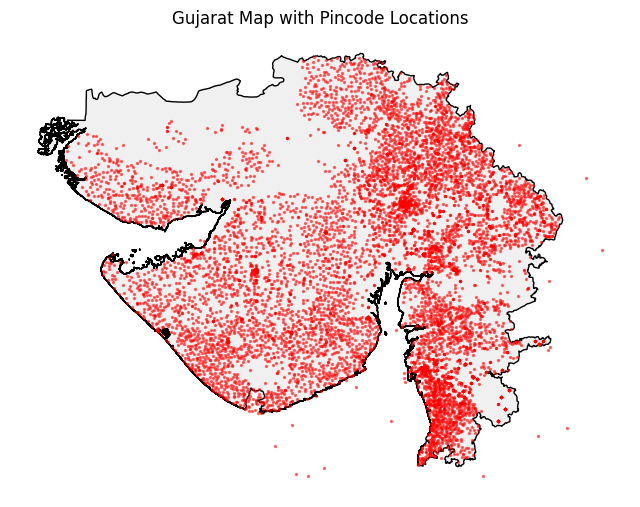

In [ ]:
home_df = home_df[
    (home_df["Latitude"].between(20, 25)) &
    (home_df["Longitude"].between(68, 75))
]

# Download india_state_geo.json from https://www.kaggle.com/datasets/sauravmishra1710/indian-state-geojson-data?resource=download

gdf_points = gpd.GeoDataFrame(
    home_df,
    geometry=gpd.points_from_xy(home_df["Longitude"], home_df["Latitude"]),
    crs="EPSG:4326"
)

india = gpd.read_file("india_state_geo.json")

home = india[india["NAME_1"].str.upper() == "GUJARAT"]

gdf_points = gdf_points.to_crs(home.crs)

fig, ax = plt.subplots(figsize=(8, 8))

home.plot(ax=ax, color="#f0f0f0", edgecolor="black", linewidth=1)

gdf_points.plot(ax=ax, color="red", markersize=2, alpha=0.5)

ax.set_title("Gujarat Map with Pincode Locations")
ax.set_axis_off()

plt.show()

3 : K-Means

In [ ]:
def kmeans(X, k, max_iters=100):
    np.random.seed(42)

    # initialize centroids randomly
    indices = np.random.choice(len(X), k, replace=False)
    centroids = X[indices]

    for _ in range(max_iters):
        distances = np.linalg.norm(X[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = np.array([
            X[labels == i].mean(axis=0) if len(X[labels == i]) > 0 else centroids[i]
            for i in range(k)
        ])

        if np.allclose(centroids, new_centroids):
            break

        centroids = new_centroids

    return labels, centroids

4 : Running the K-Means Algorithm

In [ ]:
X = home_df[["Latitude", "Longitude"]].values
k = 5
labels, centroids = kmeans(X, k)

home_df["cluster"] = labels

5 : Clustered Visualisation

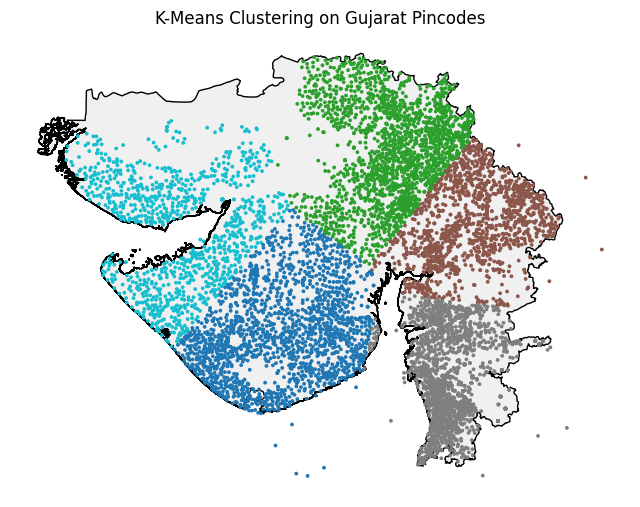

In [54]:
fig, ax = plt.subplots(figsize=(8, 8))

home.plot(ax=ax, color="#f0f0f0", edgecolor="black")

gdf_points.plot(
    ax=ax,
    column="cluster",
    cmap="tab10",
    markersize=3,
)

ax.set_title("K-Means Clustering on Gujarat Pincodes")
ax.set_axis_off()

plt.show()